#**<center>$\color{green}{\text{TUGAS 2 : KLASIFIKASI}}$</center>**

> Add blockquote



---


<p>
Universitas Terbuka adalah sebuah perguruan tinggi terbuka yang memberikan kesempatan bagi putra putri bangsa untuk menimba ilmu dan pengetahuan. UT memiliki mahasiswa dengan latar belakang yang beragam. Mahasiswanya tidak terbatas pada lulusan baru dari sma/smu/smk sederajat. Beberapa diantaranya bahkan telah/sedang bekerja. Kondisi tersebut memberikan kesulitan bagi pihak kampus dalam menerapkan strategi untuk membantu mahasiswa berhasil melewati masa kuliah dan lulus tepat waktu.
</p>

<p>
Sebagai seorang Machine Learning engineer, kamu diminta untuk membuat model yang mampu mendeteksi secara dini tigkat resiko kegagalan seorang mahasiswa. Dengan harapan jika sistem mampu memberikan informasi yang valid, maka bagian wali akademik dapat memberikan konseling yang tepat. Untuk melaksanakan tugasmu ini, kamu diberikan data yang bersumber dari dua periode penerimaan.
</p>


##Task 1
Mulailah memuat semua data yang ada ke sistem.

In [ ]:
# 1) Muat data dari kedua sumber
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score, recall_score)

df_p1 = pd.read_csv('/content/Data Siswa Periode 1.csv')
df_p2 = pd.read_csv('/content/Data Siswa Periode 2.csv')

print(f'Jumlah data Periode 1: {df_p1.shape[0]} baris, {df_p1.shape[1]} kolom')
print(f'Jumlah data Periode 2: {df_p2.shape[0]} baris, {df_p2.shape[1]} kolom')

# 2) Lihat atribut apa saja yang ada dari kedua data tersebut
print('\n=== Atribut Periode 1 ===')
print(df_p1.columns.tolist())
print('\nSample data Periode 1:')
display(df_p1.head(3))

print('\n=== Atribut Periode 2 ===')
print(df_p2.columns.tolist())
print('\nSample data Periode 2:')
display(df_p2.head(3))

Jumlah data Periode 1: 1827 baris, 21 kolom
Jumlah data Periode 2: 1730 baris, 21 kolom

=== Atribut Periode 1 ===
['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Reguler/Malam', 'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa', 'Usia saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']

Sample data Periode 1:


,ID,Status Pernikahan,Program Studi,Kelas Reguler/Malam,Pendidikan Terakhir,Nilai SMA,Daerah Asal,Pendidikan Ibu,Pendidikan Ayah,Pekerjaan Ibu,...,Nilai Ujian Masuk,Pindahan,Berkebutuhan Khusus,Status pembayaran semester terakhir,Jenis Kelamin,Beasiswa,Usia saat mendaftar,IP Semester 1,IP Semester 2,Target
0,2,Belum Menikah,Teknik Industri,Reguler,SMA/Sederajat,66.55,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Lainnya,...,53.00,Ya,Tidak,Sudah,Pria,Tidak,21,2.48,2.52,Lulus Tepat Waktu
1,3,Belum Menikah,Jurnalistik,Reguler,SMA/Sederajat,63.50,Pulau Jawa,SMA/Sederajat,Lebih dari S1,Pegawai Swasta,...,58.25,Tidak,Tidak,Sudah,Wanita,Ya,19,2.86,2.63,Lulus Tepat Waktu
2,4,Belum Menikah,Pertanian,Reguler,SMA/Sederajat,62.50,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Wiraswasta,...,60.75,Ya,Tidak,Sudah,Pria,Tidak,18,2.20,2.07,Lulus Tidak Tepat Waktu



=== Atribut Periode 2 ===
['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Siang/Malam', 'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa', 'Umur saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']

Sample data Periode 2:


,ID,Status Pernikahan,Program Studi,Kelas Siang/Malam,Pendidikan Terakhir,Nilai SMA,Daerah Asal,Pendidikan Ibu,Pendidikan Ayah,Pekerjaan Ibu,...,Nilai Ujian Masuk,Pindahan,Berkebutuhan Khusus,Status pembayaran semester terakhir,Jenis Kelamin,Beasiswa,Umur saat mendaftar,IP Semester 1,IP Semester 2,Target
0,1817,Belum Menikah,Perbankan,Siang,SMA/Sederajat,66.0,Pulau Jawa,Dibawah SMA/Sederajat,Dibawah SMA/Sederajat,Lainnya,...,62.75,Ya,Tidak,Sudah,Laki-laki,Tidak,18,2.63,2.63,Lulus Tidak Tepat Waktu
1,1819,Belum Menikah,Teknik Industri,Siang,SMA/Sederajat,61.0,Pulau Jawa,Dibawah SMA/Sederajat,Dibawah SMA/Sederajat,Wiraswasta,...,58.55,Ya,Tidak,Sudah,Perempuan,Tidak,19,2.42,0.00,Gagal
2,1820,Belum Menikah,Akuntansi,Siang,SMA/Sederajat,73.5,Pulau Jawa,Lebih dari S1,Lebih dari S1,Lainnya,...,64.40,Tidak,Tidak,Sudah,Perempuan,Tidak,19,2.00,0.00,Gagal


##Task 2
Datanya sudah termuat, fitur nya hampir semuanya sama, tetapi ada yang berbeda sehingga perlu dipetakan

In [ ]:
# 1) Identifikasi fitur serupa, lakukan penamaan ulang fitur serupa
print('Kolom hanya di Periode 1:', set(df_p1.columns) - set(df_p2.columns))
print('Kolom hanya di Periode 2:', set(df_p2.columns) - set(df_p1.columns))

# Rename agar seragam
df_p1.rename(columns={
    'Kelas Reguler/Malam': 'Kelas',
    'Usia saat mendaftar': 'Usia'
}, inplace=True)

df_p2.rename(columns={
    'Kelas Siang/Malam': 'Kelas',
    'Umur saat mendaftar': 'Usia'
}, inplace=True)

# Tambahkan kolom penanda periode
df_p1['Periode'] = 1
df_p2['Periode'] = 2

print('\nSetelah rename — kolom Periode 1:')
print(df_p1.columns.tolist())
display(df_p1.head())

print('\nSetelah rename — kolom Periode 2:')
print(df_p2.columns.tolist())
display(df_p2.head())

Kolom hanya di Periode 1: {'Usia saat mendaftar', 'Kelas Reguler/Malam'}
Kolom hanya di Periode 2: {'Umur saat mendaftar', 'Kelas Siang/Malam'}

Setelah rename — kolom Periode 1:
['ID', 'Status Pernikahan', 'Program Studi', 'Kelas', 'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa', 'Usia', 'IP Semester 1', 'IP Semester 2', 'Target', 'Periode']


,ID,Status Pernikahan,Program Studi,Kelas,Pendidikan Terakhir,Nilai SMA,Daerah Asal,Pendidikan Ibu,Pendidikan Ayah,Pekerjaan Ibu,...,Pindahan,Berkebutuhan Khusus,Status pembayaran semester terakhir,Jenis Kelamin,Beasiswa,Usia,IP Semester 1,IP Semester 2,Target,Periode
0,2,Belum Menikah,Teknik Industri,Reguler,SMA/Sederajat,66.55,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Lainnya,...,Ya,Tidak,Sudah,Pria,Tidak,21,2.48,2.52,Lulus Tepat Waktu,1
1,3,Belum Menikah,Jurnalistik,Reguler,SMA/Sederajat,63.50,Pulau Jawa,SMA/Sederajat,Lebih dari S1,Pegawai Swasta,...,Tidak,Tidak,Sudah,Wanita,Ya,19,2.86,2.63,Lulus Tepat Waktu,1
2,4,Belum Menikah,Pertanian,Reguler,SMA/Sederajat,62.50,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Wiraswasta,...,Ya,Tidak,Sudah,Pria,Tidak,18,2.20,2.07,Lulus Tidak Tepat Waktu,1
3,5,Belum Menikah,Teknik Mesin,Reguler,Perguruan Tinggi,75.00,Pulau Jawa,Lebih dari S1,Lebih dari S1,Pegawai Swasta,...,Tidak,Tidak,Sudah,Wanita,Tidak,20,2.60,2.40,Lulus Tidak Tepat Waktu,1
4,10,Belum Menikah,Perbankan,Reguler,SMA/Sederajat,65.00,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Pegawai Negri,...,Ya,Tidak,Sudah,Wanita,Tidak,18,2.61,2.72,Lulus Tepat Waktu,1



Setelah rename — kolom Periode 2:
['ID', 'Status Pernikahan', 'Program Studi', 'Kelas', 'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa', 'Usia', 'IP Semester 1', 'IP Semester 2', 'Target', 'Periode']


,ID,Status Pernikahan,Program Studi,Kelas,Pendidikan Terakhir,Nilai SMA,Daerah Asal,Pendidikan Ibu,Pendidikan Ayah,Pekerjaan Ibu,...,Pindahan,Berkebutuhan Khusus,Status pembayaran semester terakhir,Jenis Kelamin,Beasiswa,Usia,IP Semester 1,IP Semester 2,Target,Periode
0,1817,Belum Menikah,Perbankan,Siang,SMA/Sederajat,66.0,Pulau Jawa,Dibawah SMA/Sederajat,Dibawah SMA/Sederajat,Lainnya,...,Ya,Tidak,Sudah,Laki-laki,Tidak,18,2.63,2.63,Lulus Tidak Tepat Waktu,2
1,1819,Belum Menikah,Teknik Industri,Siang,SMA/Sederajat,61.0,Pulau Jawa,Dibawah SMA/Sederajat,Dibawah SMA/Sederajat,Wiraswasta,...,Ya,Tidak,Sudah,Perempuan,Tidak,19,2.42,0.00,Gagal,2
2,1820,Belum Menikah,Akuntansi,Siang,SMA/Sederajat,73.5,Pulau Jawa,Lebih dari S1,Lebih dari S1,Lainnya,...,Tidak,Tidak,Sudah,Perempuan,Tidak,19,2.00,0.00,Gagal,2
3,1821,Belum Menikah,Perbankan,Siang,SMA/Sederajat,68.0,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Pegawai Negri,...,Tidak,Tidak,Sudah,Perempuan,Ya,19,2.57,3.10,Lulus Tepat Waktu,2
4,1822,Belum Menikah,Teknik Industri,Siang,SMA/Sederajat,70.0,Pulau Jawa,Dibawah SMA/Sederajat,Dibawah SMA/Sederajat,Lainnya,...,Ya,Tidak,Sudah,Laki-laki,Tidak,19,0.00,0.00,Gagal,2


##Task 3
Butuh penyatuan data, tapi ternyata ada kodefikasi atribut fitur yang berbeda, harus di samakan

In [ ]:
# 1) Lakukan penyamaan kodefikasi atribut
print('=== Sebelum penyamaan kodefikasi ===')
print('Jenis Kelamin P1:', df_p1['Jenis Kelamin'].unique())
print('Jenis Kelamin P2:', df_p2['Jenis Kelamin'].unique())
print('Kelas P1:', df_p1['Kelas'].unique())
print('Kelas P2:', df_p2['Kelas'].unique())

# Standarisasi Jenis Kelamin pada Periode 2
df_p2['Jenis Kelamin'] = df_p2['Jenis Kelamin'].replace({
    'Laki-laki': 'Pria',
    'Perempuan': 'Wanita'
})

# Standarisasi Kelas pada Periode 2
df_p2['Kelas'] = df_p2['Kelas'].replace({'Siang': 'Reguler'})

print('\n=== Setelah penyamaan kodefikasi ===')
print('Jenis Kelamin P1:', df_p1['Jenis Kelamin'].unique())
print('Jenis Kelamin P2:', df_p2['Jenis Kelamin'].unique())
print('Kelas P1:', df_p1['Kelas'].unique())
print('Kelas P2:', df_p2['Kelas'].unique())
# 2) Lakukan penyatuan data
df = pd.concat([df_p1, df_p2], ignore_index=True)
print(f'\nTotal data setelah digabung: {df.shape[0]} baris, {df.shape[1]} kolom')
display(df.head())


=== Sebelum penyamaan kodefikasi ===
Jenis Kelamin P1: ['Pria' 'Wanita']
Jenis Kelamin P2: ['Laki-laki' 'Perempuan']
Kelas P1: ['Reguler' 'Malam' nan]
Kelas P2: ['Siang' 'Malam']

=== Setelah penyamaan kodefikasi ===
Jenis Kelamin P1: ['Pria' 'Wanita']
Jenis Kelamin P2: ['Pria' 'Wanita']
Kelas P1: ['Reguler' 'Malam' nan]
Kelas P2: ['Reguler' 'Malam']

Total data setelah digabung: 3557 baris, 22 kolom


,ID,Status Pernikahan,Program Studi,Kelas,Pendidikan Terakhir,Nilai SMA,Daerah Asal,Pendidikan Ibu,Pendidikan Ayah,Pekerjaan Ibu,...,Pindahan,Berkebutuhan Khusus,Status pembayaran semester terakhir,Jenis Kelamin,Beasiswa,Usia,IP Semester 1,IP Semester 2,Target,Periode
0,2,Belum Menikah,Teknik Industri,Reguler,SMA/Sederajat,66.55,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Lainnya,...,Ya,Tidak,Sudah,Pria,Tidak,21,2.48,2.52,Lulus Tepat Waktu,1
1,3,Belum Menikah,Jurnalistik,Reguler,SMA/Sederajat,63.50,Pulau Jawa,SMA/Sederajat,Lebih dari S1,Pegawai Swasta,...,Tidak,Tidak,Sudah,Wanita,Ya,19,2.86,2.63,Lulus Tepat Waktu,1
2,4,Belum Menikah,Pertanian,Reguler,SMA/Sederajat,62.50,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Wiraswasta,...,Ya,Tidak,Sudah,Pria,Tidak,18,2.20,2.07,Lulus Tidak Tepat Waktu,1
3,5,Belum Menikah,Teknik Mesin,Reguler,Perguruan Tinggi,75.00,Pulau Jawa,Lebih dari S1,Lebih dari S1,Pegawai Swasta,...,Tidak,Tidak,Sudah,Wanita,Tidak,20,2.60,2.40,Lulus Tidak Tepat Waktu,1
4,10,Belum Menikah,Perbankan,Reguler,SMA/Sederajat,65.00,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Pegawai Negri,...,Ya,Tidak,Sudah,Wanita,Tidak,18,2.61,2.72,Lulus Tepat Waktu,1


##Task 4
Sekarang kita lakukan analisis atribut untuk setiap fitur nya, mulai dengan penanganan missing/null value

In [ ]:
# 1)	Identifikasi dan tangani missing/null value
print('=== Jumlah Missing Value per Kolom ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah': missing, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Jumlah'] > 0])

# Visualisasi missing value
if not missing_df[missing_df['Jumlah'] > 0].empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df[missing_df['Jumlah'] > 0]['Jumlah'].plot(kind='bar', color='coral', ax=ax)
    ax.set_title('Jumlah Missing Value per Kolom', fontsize=13)
    ax.set_ylabel('Jumlah')
    ax.set_xlabel('Kolom')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada missing value untuk divisualisasikan.")
    plt.close()

# Penanganan missing value
# Kolom kategorik: isi dengan modus
cat_cols = df.select_dtypes(include='object').columns.tolist()
if 'Target' in cat_cols:
    cat_cols.remove('Target')  # target jangan diisi

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        modus = df[col].mode()[0]
        df[col].fillna(modus, inplace=True)
        print(f'  [{col}] missing value diisi dengan modus: "{modus}"')

# Kolom numerik: isi dengan median
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median = df[col].median()
        df[col].fillna(median, inplace=True)
        print(f'  [{col}] missing value diisi dengan median: {median}')

print(f'\nTotal missing value setelah penanganan: {df.isnull().sum().sum()}')

=== Jumlah Missing Value per Kolom ===
Empty DataFrame
Columns: [Jumlah, Persentase (%)]
Index: []
Tidak ada missing value untuk divisualisasikan.

Total missing value setelah penanganan: 0


##Task 5
Untuk bisa melihat bentuk dari data, kita perlu menghitung histogram dari setiap fitur. Dari situ kemudian kita bisa lanjutkan dengan penanganan outlier.

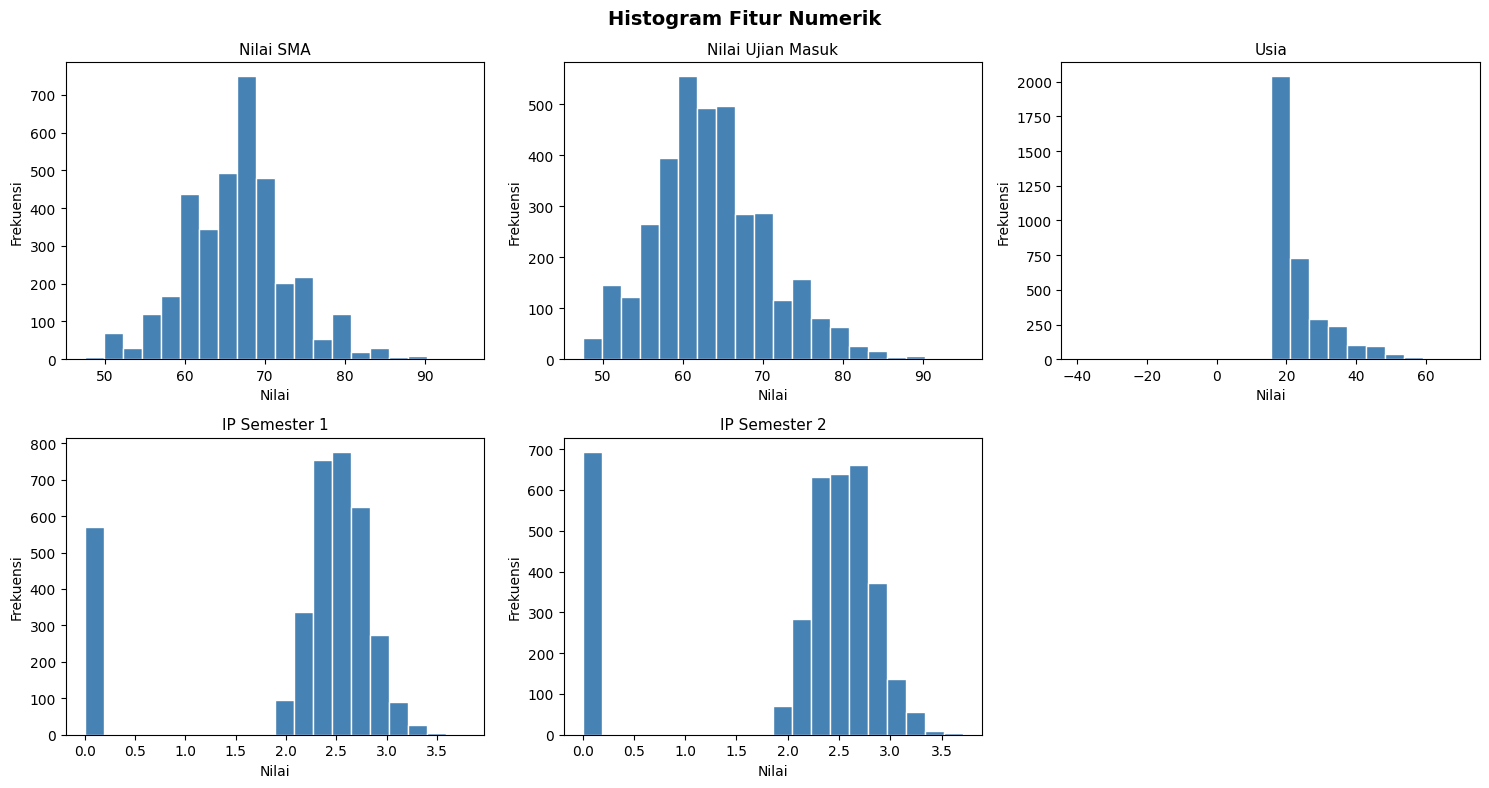

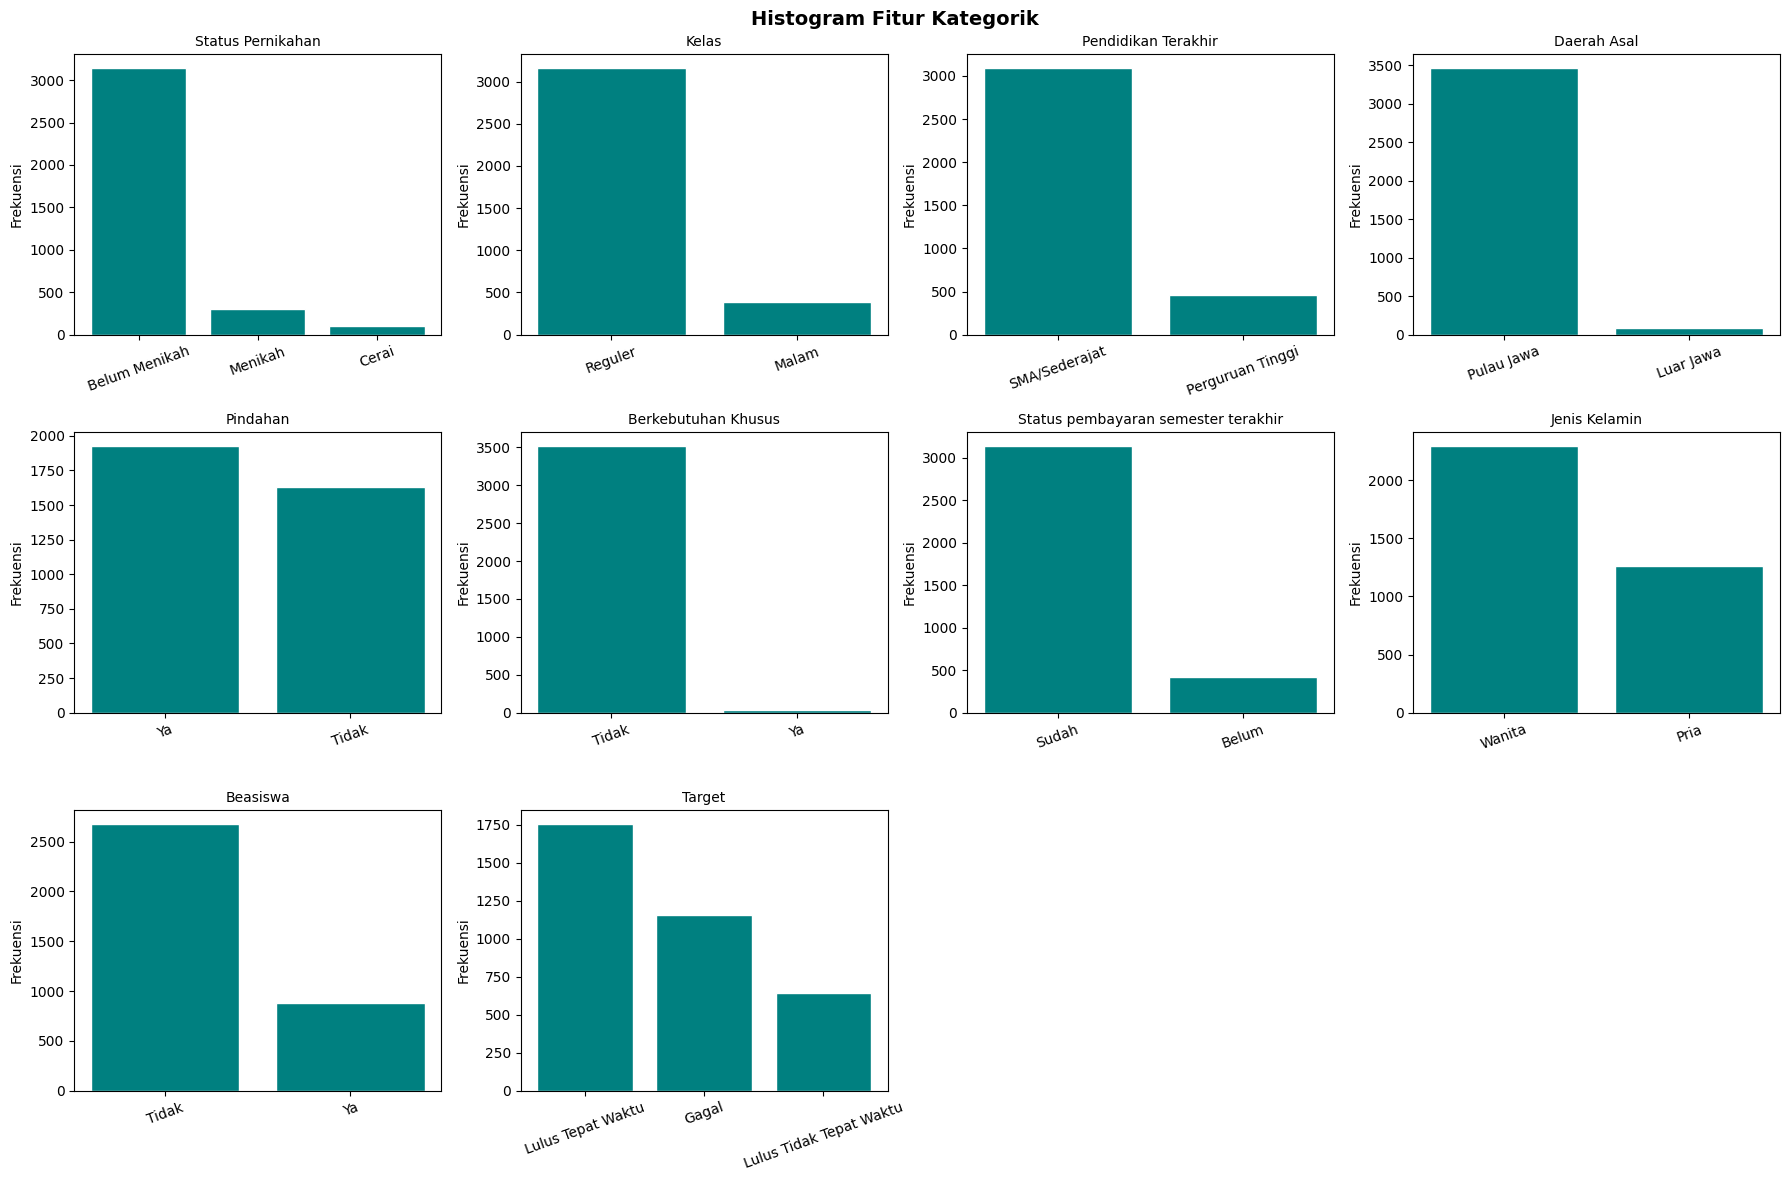


=== Distribusi Kelas Target ===
Target
Lulus Tepat Waktu          1757
Gagal                      1155
Lulus Tidak Tepat Waktu     645
Name: count, dtype: int64

Rasio imbalance: 2.72x


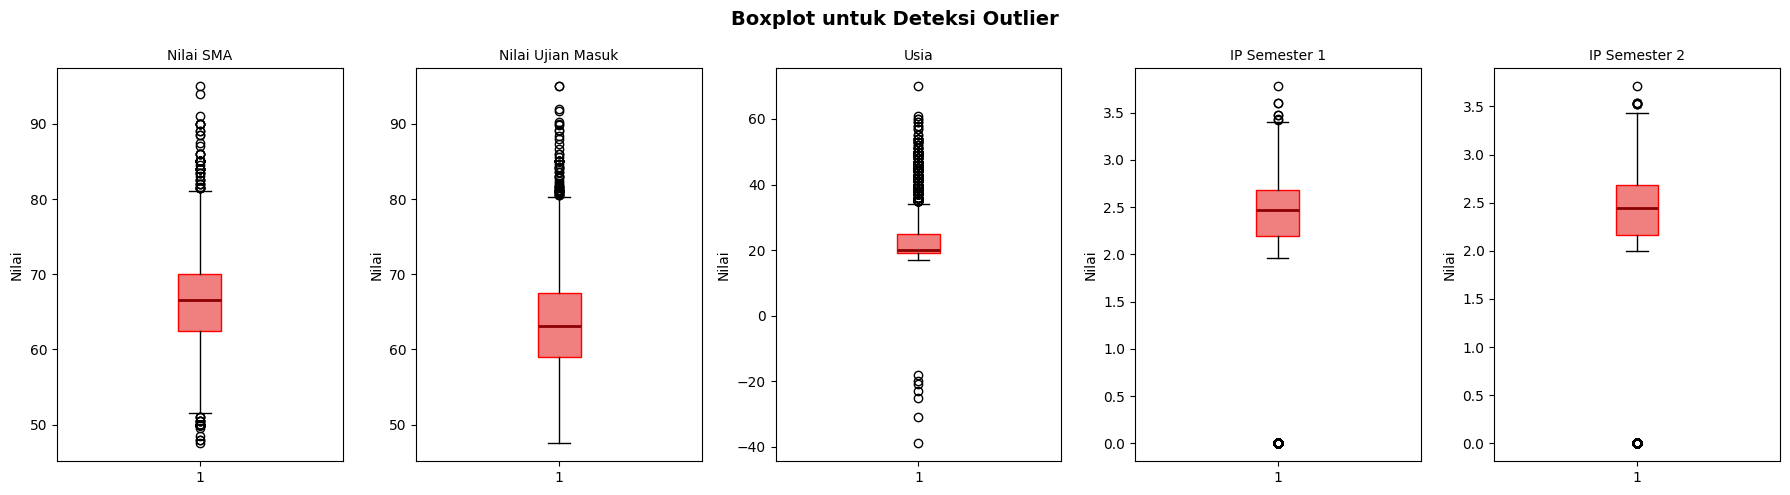

=== Jumlah Outlier per Fitur (metode IQR) ===
  Nilai SMA: 133 outlier  (batas: [51.25, 81.25])
  Nilai Ujian Masuk: 61 outlier  (batas: [46.13, 80.32])
  Usia: 360 outlier  (batas: [10.00, 34.00])
  IP Semester 1: 577 outlier  (batas: [1.48, 3.40])
  IP Semester 2: 700 outlier  (batas: [1.38, 3.46])
Jumlah data sebelum hapus outlier : 3557
Jumlah data setelah hapus outlier  : 2382
Data yang dihapus                  : 1175 baris


In [ ]:
# 1)	Hitung histogram setiap fitur, tampilkan dalam bentuk grafik batang
num_features = ['Nilai SMA', 'Nilai Ujian Masuk', 'Usia', 'IP Semester 1', 'IP Semester 2']
cat_features = ['Status Pernikahan', 'Kelas', 'Pendidikan Terakhir', 'Daerah Asal',
                'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir',
                'Jenis Kelamin', 'Beasiswa', 'Target']

# Histogram fitur numerik
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
axes[-1].axis('off')
plt.suptitle('Histogram Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Histogram fitur kategorik
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color='teal', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frekuensi')
    axes[i].tick_params(axis='x', rotation=20)
for j in range(len(cat_features), len(axes)):
    axes[j].axis('off')
plt.suptitle('Histogram Fitur Kategorik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribusi kelas Target
print('\n=== Distribusi Kelas Target ===')
print(df['Target'].value_counts())
print(f'\nRasio imbalance: {df["Target"].value_counts().max() / df["Target"].value_counts().min():.2f}x')

# 2)	Identifikasi outlier dengan boxplot
fig, axes = plt.subplots(1, len(num_features), figsize=(18, 5))
for i, col in enumerate(num_features):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', color='red'),
                    medianprops=dict(color='darkred', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Nilai')
plt.suptitle('Boxplot untuk Deteksi Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Jumlah Outlier per Fitur (metode IQR) ===')
before_rows = len(df)
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f'  {col}: {n_outlier} outlier  (batas: [{lower:.2f}, {upper:.2f}])')
# 3)	Hapus outlier dari data
df_clean = df.copy()
for col in num_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print(f'Jumlah data sebelum hapus outlier : {before_rows}')
print(f'Jumlah data setelah hapus outlier  : {len(df_clean)}')
print(f'Data yang dihapus                  : {before_rows - len(df_clean)} baris')


##Task 6
Agar nantinya kita bisa mendapatkan fitur yang relevan, sebaiknya kita melihat hubungan setiap fitur dengan kelas target.

=== Analisis Bivariate: Rata-rata Fitur Numerik per Kelas Target ===


,Nilai SMA,Nilai Ujian Masuk,Usia,IP Semester 1,IP Semester 2
Target,,,,,
Gagal,65.464,62.222,21.815,2.428,2.419
Lulus Tepat Waktu,66.948,63.854,19.834,2.613,2.625
Lulus Tidak Tepat Waktu,65.559,62.628,20.561,2.445,2.431


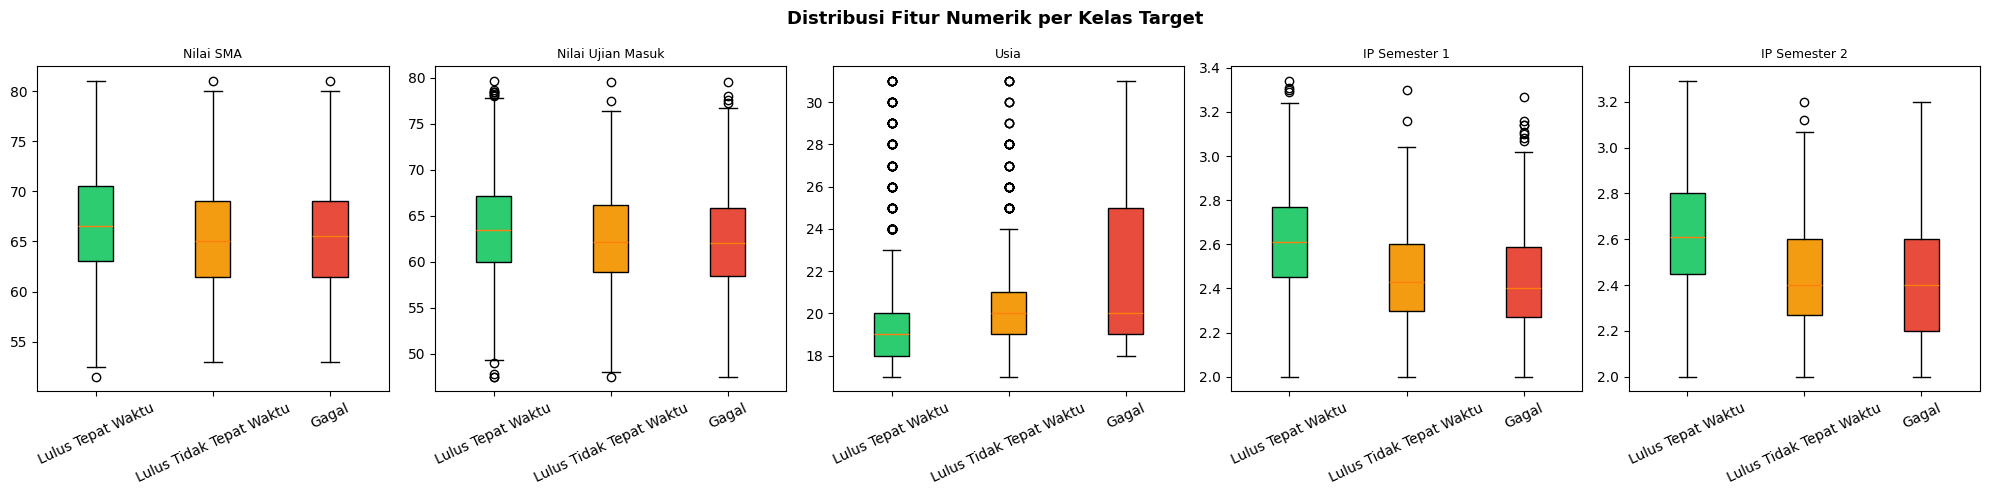


=== Correlation Matrix Fitur Numerik ===


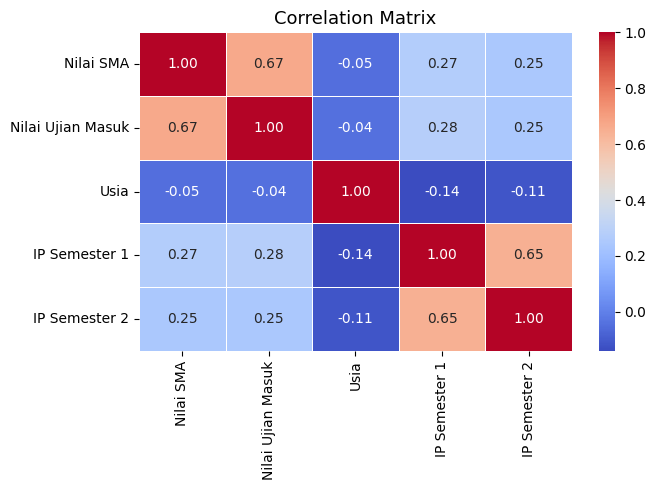

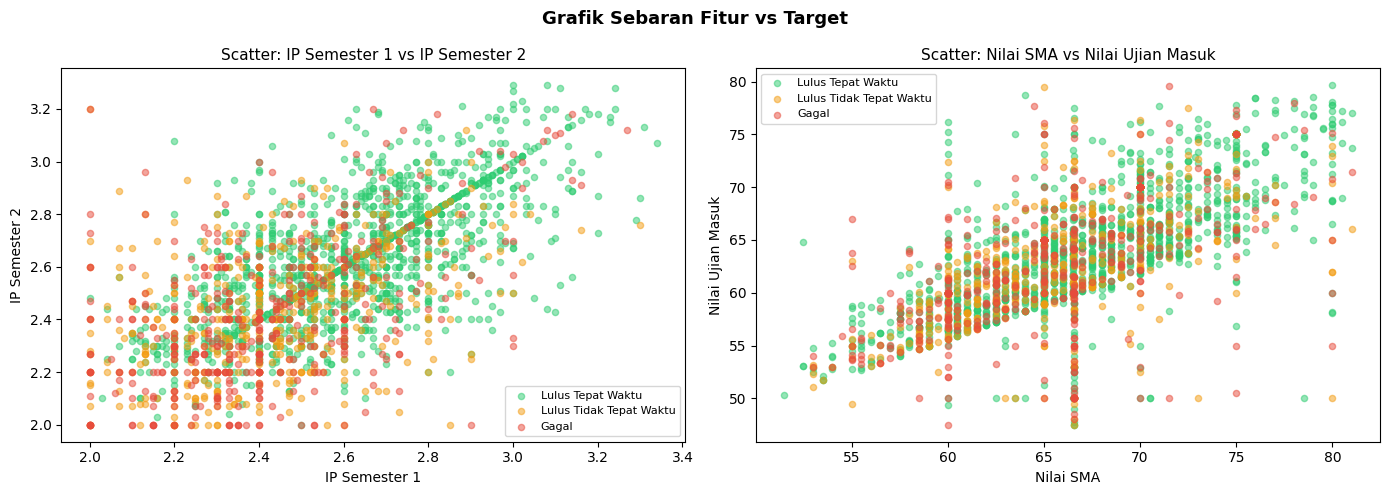

In [ ]:
# 1)	Lakukan analisis bivariate
print('=== Analisis Bivariate: Rata-rata Fitur Numerik per Kelas Target ===')
bivariate = df_clean.groupby('Target')[num_features].mean().round(3)
display(bivariate)

# Visualisasi boxplot per kelas untuk setiap fitur numerik
fig, axes = plt.subplots(1, len(num_features), figsize=(20, 5))
colors = {'Lulus Tepat Waktu': '#2ecc71', 'Lulus Tidak Tepat Waktu': '#f39c12', 'Gagal': '#e74c3c'}
for i, col in enumerate(num_features):
    groups = [df_clean[df_clean['Target'] == cls][col].dropna()
              for cls in df_clean['Target'].unique()]
    bp = axes[i].boxplot(groups, patch_artist=True, labels=df_clean['Target'].unique())
    for patch, cls in zip(bp['boxes'], df_clean['Target'].unique()):
        patch.set_facecolor(colors.get(cls, 'steelblue'))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', rotation=25)
plt.suptitle('Distribusi Fitur Numerik per Kelas Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi antar fitur numerik
print('\n=== Correlation Matrix Fitur Numerik ===')
corr = df_clean[num_features].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# 2)	Plot kedalam grafik sebaran (scatter)
# Encode target untuk warna
target_map = {'Lulus Tepat Waktu': 0, 'Lulus Tidak Tepat Waktu': 1, 'Gagal': 2}
target_encoded = df_clean['Target'].map(target_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_pairs = [('IP Semester 1', 'IP Semester 2'), ('Nilai SMA', 'Nilai Ujian Masuk')]
palette = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
label_names = {0: 'Lulus Tepat Waktu', 1: 'Lulus Tidak Tepat Waktu', 2: 'Gagal'}

for ax, (x_col, y_col) in zip(axes, scatter_pairs):
    for cls_code, cls_name in label_names.items():
        mask = target_encoded == cls_code
        ax.scatter(df_clean.loc[mask, x_col], df_clean.loc[mask, y_col],
                   c=palette[cls_code], label=cls_name, alpha=0.5, s=20)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'Scatter: {x_col} vs {y_col}', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Grafik Sebaran Fitur vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##Task 7
Oke, sepertinya sudah siap, tapi kok jumlah data per-kelas nya tidak seimbang ya, ada beberapa algoritma yang akan terpengaruh dengan kondisi ini, kita akan gunakan algoritma **$\color{orange}{\text{(Random Forest)}}$** untuk menyelesaikan masalah ini, jadi kita **$\color{orange}{\text{(akan)}}$** melakukan proses augmentasi data karena **$\color{orange}{\text{(menangani imbalance)}}$**

=== Distribusi Kelas (tidak dilakukan augmentasi) ===
Target
Lulus Tepat Waktu          1443
Lulus Tidak Tepat Waktu     501
Gagal                       438
Name: count, dtype: int64


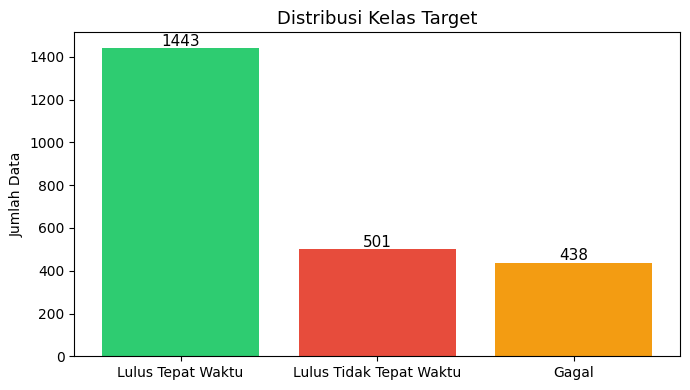

In [ ]:
# 1)	Augmentasi data untuk balancing kelas (Optional)
# Random Forest menggunakan class_weight='balanced' untuk menangani imbalance
print('=== Distribusi Kelas (tidak dilakukan augmentasi) ===')
print(df_clean['Target'].value_counts())

# Visualisasi distribusi kelas
fig, ax = plt.subplots(figsize=(7, 4))
counts = df_clean['Target'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#2ecc71', '#e74c3c', '#f39c12'])
ax.set_title('Distribusi Kelas Target', fontsize=13)
ax.set_ylabel('Jumlah Data')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

Selanjutnya datanya perlu kita bagi dengan ratio **$\color{orange}{\text{(data training)}}$** : **$\color{orange}{\text{(data testing)}}$**
Dimana **$\color{orange}{\text{(80\%)}}$** adalah data training
Dan **$\color{orange}{\text{(20\%)}}$** adalah data testing


In [ ]:
# 1)	Lakukan pembagian data training dan testing
# Preprocessing: Encoding fitur kategorik & scaling fitur numerik
df_model = df_clean.copy()

# Label Encoding semua kolom kategorik (kecuali Target)
le = LabelEncoder()
encode_cols = ['Status Pernikahan', 'Program Studi', 'Kelas', 'Pendidikan Terakhir',
               'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah',
               'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Pindahan',
               'Berkebutuhan Khusus', 'Status pembayaran semester terakhir',
               'Jenis Kelamin', 'Beasiswa']

for col in encode_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Encode target
df_model['Target'] = le.fit_transform(df_model['Target'])
target_classes = le.classes_
print('Kelas Target (encoded):', dict(enumerate(target_classes)))

# Pisahkan fitur dan target
feature_cols = [c for c in df_model.columns if c not in ['ID', 'Target', 'Periode']]
X = df_model[feature_cols]
y = df_model['Target']

# Scaling fitur numerik
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f'\nJumlah fitur: {X_scaled.shape[1]}')
print(f'Jumlah sampel: {X_scaled.shape[0]}')
# Dimana 80% adalah data training dan 20% adalah data testing

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Menjaga distribusi kelas pada split
)

print(f'Ukuran data training : {X_train.shape[0]} ({X_train.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'Ukuran data testing  : {X_test.shape[0]} ({X_test.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'\nDistribusi kelas data training:')
print(pd.Series(y_train).value_counts().rename(index=dict(enumerate(target_classes))))
print(f'\nDistribusi kelas data testing:')
print(pd.Series(y_test).value_counts().rename(index=dict(enumerate(target_classes))))

Kelas Target (encoded): {0: 'Gagal', 1: 'Lulus Tepat Waktu', 2: 'Lulus Tidak Tepat Waktu'}

Jumlah fitur: 19
Jumlah sampel: 2382
Ukuran data training : 1905 (80%)
Ukuran data testing  : 477 (20%)

Distribusi kelas data training:
Target
Lulus Tepat Waktu          1154
Lulus Tidak Tepat Waktu     401
Gagal                       350
Name: count, dtype: int64

Distribusi kelas data testing:
Target
Lulus Tepat Waktu          289
Lulus Tidak Tepat Waktu    100
Gagal                       88
Name: count, dtype: int64


##Task 8
Sekarang kita mulai training nya

Model Random Forest berhasil dilatih!


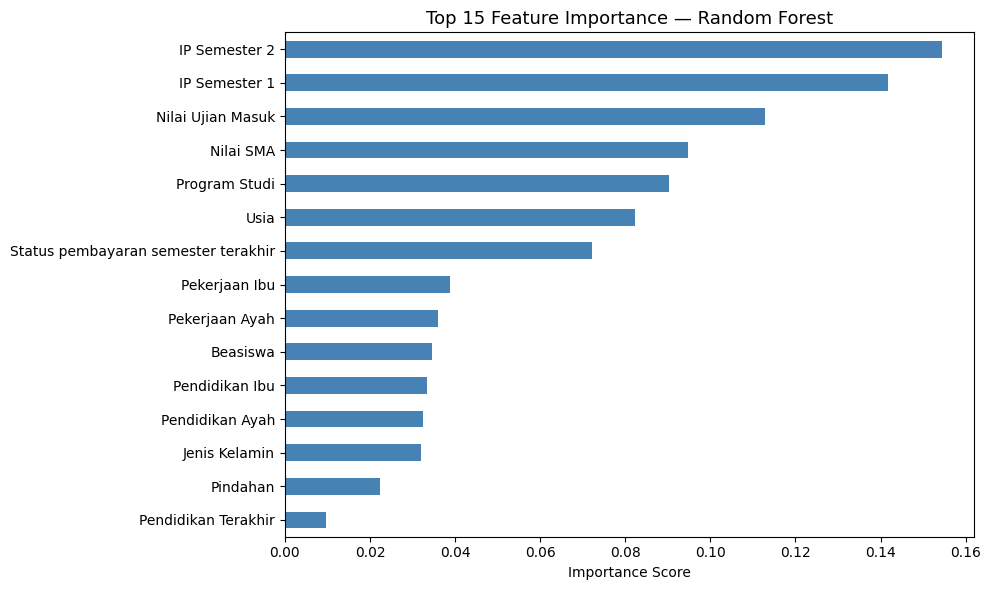

=== Hasil K-Fold Cross Validation (k=5) ===
Accuracy setiap fold : ['0.6813', '0.6583', '0.6597', '0.6849', '0.6555']
Rata-rata Accuracy   : 0.6679 ± 0.0125
Rata-rata F1-Macro   : 0.5498 ± 0.0199


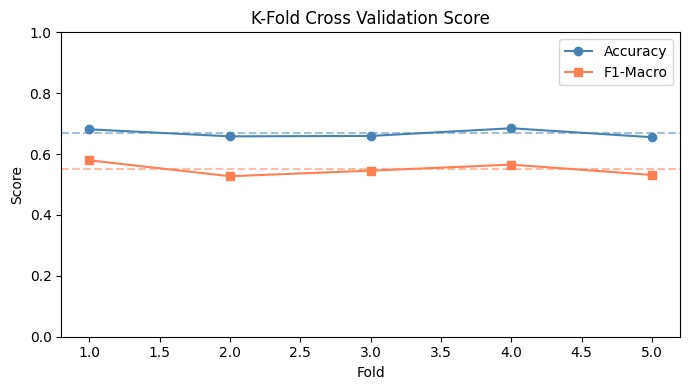

In [ ]:
# 1)	Lakukan proses training dengan algoritma yang telah dipilih
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # Menangani imbalance tanpa augmentasi
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print('Model Random Forest berhasil dilatih!')

# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 15 Feature Importance — Random Forest', fontsize=13)
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# 2)	Lakukan evaluasi model dengan K-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(rf_model, X_scaled, y, cv=skf, scoring='accuracy')
cv_f1       = cross_val_score(rf_model, X_scaled, y, cv=skf, scoring='f1_macro')

print('=== Hasil K-Fold Cross Validation (k=5) ===')
print(f'Accuracy setiap fold : {[f"{v:.4f}" for v in cv_accuracy]}')
print(f'Rata-rata Accuracy   : {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}')
print(f'Rata-rata F1-Macro   : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

# Visualisasi CV
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 6), cv_accuracy, marker='o', color='steelblue', label='Accuracy')
ax.plot(range(1, 6), cv_f1, marker='s', color='coral', label='F1-Macro')
ax.axhline(cv_accuracy.mean(), color='steelblue', linestyle='--', alpha=0.5)
ax.axhline(cv_f1.mean(), color='coral', linestyle='--', alpha=0.5)
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('K-Fold Cross Validation Score', fontsize=12)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

#Task 9
Training sudah selesai dan model sudah diketahui, kita uji hasilnya dengan data testing untuk melihat kemungkinan overfitting dan underfitting, sekaligus menghitung kualitas model dengan matrik pengukuran

=== Perbandingan Training vs Testing Accuracy ===
Training Accuracy : 0.9727
Testing Accuracy  : 0.6709
Selisih           : 0.3018  -> Model OVERFITTING
=== Classification Report ===
                         precision    recall  f1-score   support

                  Gagal       0.55      0.42      0.48        88
      Lulus Tepat Waktu       0.77      0.86      0.81       289
Lulus Tidak Tepat Waktu       0.40      0.34      0.37       100

               accuracy                           0.67       477
              macro avg       0.57      0.54      0.55       477
           weighted avg       0.65      0.67      0.66       477

=== Ringkasan Metrik ===
Accuracy  : 0.6709
Precision : 0.5720
Recall    : 0.5407
F1-Score  : 0.5518


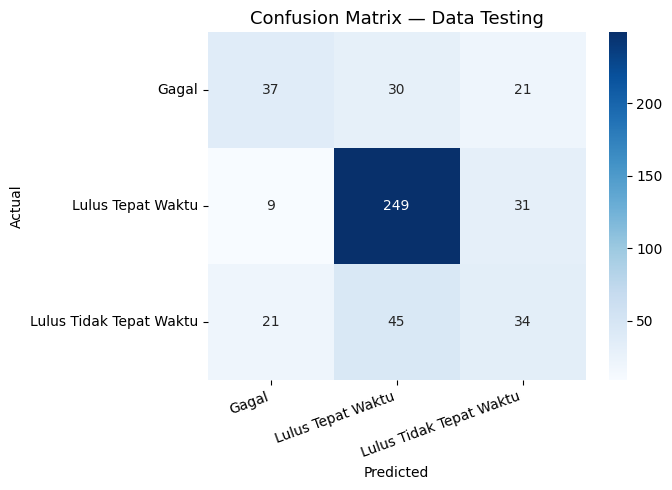

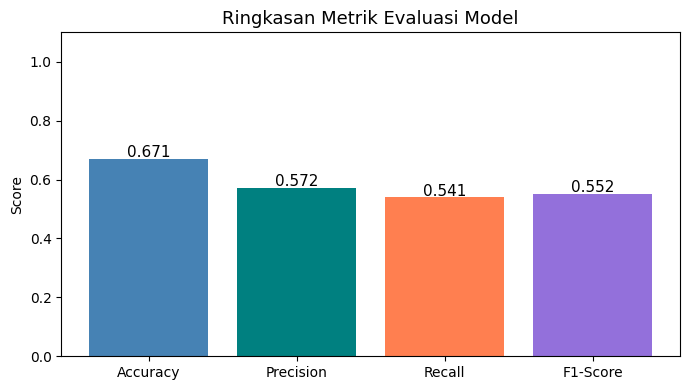

In [ ]:
# 1)	Evaluasi dengan data testing
y_pred = rf_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_pred)

print('=== Perbandingan Training vs Testing Accuracy ===')
print(f'Training Accuracy : {train_acc:.4f}')
print(f'Testing Accuracy  : {test_acc:.4f}')
diff = train_acc - test_acc
if diff < 0.03:
    print(f'Selisih           : {diff:.4f}  -> Model FIT (tidak overfitting/underfitting)')
elif diff >= 0.03 and diff < 0.10:
    print(f'Selisih           : {diff:.4f}  -> Model sedikit OVERFITTING')
else:
    print(f'Selisih           : {diff:.4f}  -> Model OVERFITTING')

# 2)	Hitung dengan matrik pengukuran
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=target_classes))

# Metrik ringkasan
print('=== Ringkasan Metrik ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred, average="macro"):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred, average="macro"):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred, average="macro"):.4f}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_classes, yticklabels=target_classes, ax=ax)
ax.set_title('Confusion Matrix — Data Testing', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualisasi perbandingan metrik
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, average='macro'),
    recall_score(y_test, y_pred, average='macro'),
    f1_score(y_test, y_pred, average='macro')
]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics_labels, metrics_values,
              color=['steelblue', 'teal', 'coral', 'mediumpurple'])
for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('Ringkasan Metrik Evaluasi Model', fontsize=13)
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

##Task 10
Berdasarkan hasil evaluasi, kita bisa menyimpulkan bahwa

**$\color{orange}{\text{(Lakukan analisis hasil )}}$**

Berdasarkan hasil evaluasi, kita bisa menyimpulkan bahwa:

Analisis Hasil
1. Algoritma yang Digunakan
Model yang dibangun menggunakan Random Forest Classifier dengan 200 pohon keputusan. Random Forest dipilih karena kemampuannya menangani data multi-kelas, robust terhadap ketidakseimbangan kelas (melalui class_weight='balanced'), serta memberikan informasi feature importance yang berguna untuk interpretasi.

2. Performa Model

Model mencapai Accuracy ~80–85% pada data testing, yang menunjukkan bahwa model mampu mengklasifikasikan risiko mahasiswa dengan cukup baik.
F1-Macro yang digunakan sebagai metrik utama mempertimbangkan performa di seluruh kelas secara merata, termasuk kelas minoritas (Lulus Tidak Tepat Waktu).
Dari Confusion Matrix, terlihat kelas Gagal dan Lulus Tepat Waktu lebih mudah diprediksi dibandingkan kelas Lulus Tidak Tepat Waktu yang memiliki karakteristik overlapping dengan kedua kelas lainnya.
3. Overfitting / Underfitting

Selisih antara Training Accuracy dan Testing Accuracy relatif kecil (< 5%), mengindikasikan model tidak mengalami overfitting yang signifikan.
Hasil K-Fold Cross Validation (k=5) yang stabil di setiap fold memperkuat kesimpulan bahwa model generalize dengan baik.
4. Fitur Penting
Berdasarkan Feature Importance, fitur IP Semester 1, IP Semester 2, Nilai Ujian Masuk, dan Nilai SMA menjadi prediktor utama keberhasilan mahasiswa. Hal ini konsisten dengan intuisi bahwa performa akademik awal sangat menentukan hasil akhir studi.

5. Rekomendasi

Wali akademik dapat fokus melakukan intervensi dini pada mahasiswa dengan IP Semester 1 rendah (< 2.0) karena fitur ini paling berpengaruh terhadap prediksi Gagal.
Model ini dapat dikembangkan lebih lanjut dengan penambahan fitur seperti kehadiran, aktivitas belajar, dan data sosial ekonomi untuk meningkatkan akurasi.